In [1]:
# 라이브러리 불러오기
import selenium.webdriver as wb
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
from tqdm import tqdm
import pandas as pd
import re # 정규표현식
from kiwipiepy import Kiwi # 키위 형태소 분석기
from wordcloud import WordCloud # 워드클라우드 생성 도구
from collections import Counter # 단어가 나온 횟수를 세주는 도구
import matplotlib.pyplot as plt #t시각화도구


# 문자열 전처리 함수 -> 숫자, 문자, (?.!,¿) 제외하고 공백으로 대체
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w) 
  w = w.strip() 
  return w

In [2]:
driver = wb.Chrome()
driver.get('https://brunch.co.kr/')

In [3]:
btn = driver.find_element(By.CSS_SELECTOR,'button#btnServiceMenuSearch')
btn.click()
time.sleep(1)

In [4]:
driver.find_element(By.CSS_SELECTOR,'input.txt_search').send_keys('성격 혼수'+'\n')

In [5]:
for i in range(10):
    body = driver.find_element(By.TAG_NAME,'body')
    body.send_keys(Keys.END)
    time.sleep(1)

In [6]:
href_list=[]
link = driver.find_elements(By.CSS_SELECTOR,'a.link_post')
for i in range(len(link)):
    href_list.append(link[i].get_attribute('href'))

In [7]:
href_list

['https://brunch.co.kr/@@dBbL/233',
 'https://brunch.co.kr/@@1FmP/1419',
 'https://brunch.co.kr/@@F4Y/163',
 'https://brunch.co.kr/@@ifbH/8',
 'https://brunch.co.kr/@@i0QU/41',
 'https://brunch.co.kr/@@Aju/155',
 'https://brunch.co.kr/@@dn9R/66',
 'https://brunch.co.kr/@@6emu/68',
 'https://brunch.co.kr/@@bNts/56',
 'https://brunch.co.kr/@@hp3p/1196',
 'https://brunch.co.kr/@@imA9/5',
 'https://brunch.co.kr/@@2dWR/30',
 'https://brunch.co.kr/@@cyXY/113',
 'https://brunch.co.kr/@@9f9q/26',
 'https://brunch.co.kr/@@aKO4/409',
 'https://brunch.co.kr/@@c9Pn/40',
 'https://brunch.co.kr/@@dIVl/568',
 'https://brunch.co.kr/@@i9or/14',
 'https://brunch.co.kr/@@idUB/22',
 'https://brunch.co.kr/@@169i/89',
 'https://brunch.co.kr/@@cug/22',
 'https://brunch.co.kr/@@do5W/399',
 'https://brunch.co.kr/@@ieXG/18',
 'https://brunch.co.kr/@@aHBw/35',
 'https://brunch.co.kr/@@iabF/16',
 'https://brunch.co.kr/@@hfQr/29',
 'https://brunch.co.kr/@@gDx6/11',
 'https://brunch.co.kr/@@aeXb/42',
 'https://brun

In [8]:
driver.get(href_list[0])
time.sleep(2)

In [9]:
result = driver.find_elements(By.CSS_SELECTOR,'div.wrap_body.text_align_left')
result[0].text

'아이들이 거짓말을 한다는 것은, 그것이 단순히 어른들의 거짓말을 흉내 내는 경우라면 충분히 이해할 수 있다. 그러나 올바르게 자란 아이들에게서 나타나는 몇몇 거짓말은 특별한 의미를 가지며, 그것은 교육자들을 분노하게 만들기보다는 오히려 숙고하게 만들어야 한다. 이러한 거짓말들은 지나치게 강한 사랑의 동기 영향 아래 발생하며, 아이와 그가 사랑하는 사람 사이에 오해를 불러올 때 치명적 결과를 초래하기도 한다.\n\nI\n일곱 살 된 소녀(초등학교 2학년)는 부활절 달걀을 칠할 물감을 사기 위해 아버지에게 돈을 요구했다. 그러나 아버지는 돈이 없다는 이유로 거절했다. 잠시 뒤, 아이는 고인이 된 지역 영주의 부인을 위해 화환을 마련하는 데 쓸 돈을 내라고 아버지에게 요청했다. 각 학급 아이들은 모두 50페니히씩 내야 했다. 아버지는 그녀에게 10마르크를 주었고, 아이는 그 돈으로 자신의 몫을 지불한 뒤, 아버지 책상 위에 9마르크를 올려놓고, 남은 50페니히로는 물감을 사서 놀이장 안에 숨겨 두었다. 식탁에서 아버지가 의심스럽게, 사라진 50페니히로 무슨 일을 했는지, 그것으로 물감을 산 것이 아닌지 물었다. 아이는 부인했지만, 두 살 많은 오빠가, 함께 달걀을 칠할 계획이었던 그는, 동생을 폭로했다. 결국 물감은 장 안에서 발견되었다. 화가 난 아버지는 아이를 어머니에게 맡겨 심한 체벌을 하게 했다. 어머니는 곧 아이가 얼마나 절망에 빠졌는지 깨닫고는 충격을 받았다. 그래서 벌 후에 아이를 달래주며 산책을 함께 나갔다. 그러나 이 사건의 효과는 지워지지 않았고, 환자 자신이 “청소년기의 전환점”이라 부를 만큼 결정적이었다.\n\n그녀는 그전까지는 야생적이고 자신감 있는 아이였으나, 그때부터 수줍고 소극적인 성격으로 바뀌었다. 약혼 시절, 어머니가 혼수와 가구를 마련해주자 이해할 수 없는 분노에 휩싸였다. 그것은 자신의 돈이므로 다른 사람이 그것을 사서는 안 된다는 생각이 떠올랐던 것이다. 젊은 아내가 된 후에도 남편에게 개인적 필요를 위한 지출을 요구하는 것을

In [10]:
driver = wb.Chrome()
f = open('./data/브런치 성격 혼수 검색.txt','w')

# 링크 반복
for i in tqdm(range(len(href_list))):
    driver.get(href_list[i])
    time.sleep(2)


    result = driver.find_elements(By.CSS_SELECTOR,'div.wrap_body.text_align_left')
    for j in range(len(result)):
        content = preprocess_sentence_kr(result[j].text)
        f.write(content)

f.close()

100%|██████████| 97/97 [04:51<00:00,  3.01s/it]


In [11]:
preprocess_sentence_kr(result[0].text)

'예지동의 시계골목, 이 바닥에 기술자들은 몇십 년을 시계 고치는 단순한 일로 밥 걱정 없이 먹고, 집 사고 애들 결혼시켰다. 이제 그 좋았던 그 시절은 아듀이다 나의 오메가 시계는 오랫동안 내 서랍 속에 있었다. 주인이 아버지였을 때 매일 작동했는데 아들에게 전해진 후로, 언제부터 멈추었는지? 기억은 없다. 이따금씩 유리 안쪽에 결로가 생겨 그걸 없애겠다고 유리면에 열을 가하기도 했는데 물방울은 잠시 없어졌다가 다시 생겼다. 책상 서랍 속에 오래 있었고 고장상태를 잘 유지했다. 나는 세운상가의 사람 사는 분위기를 좋아했었다. 탱크 빼고는 못 만드는 게 없다는 기술과 그 기술에 뿌듯해했다. 특별하게 볼 일이 없어도 한 번씩 들렀다. 총각 때 월급날에 를 사려고 종로 5가 음반가게를 들렀고, 하릴없이 예지동 복잡한 미로를 소요했다. 그 많은 가게가 먹고사는 게 신기하기도 했다. 귀가할 때는 왠지 모를 포만감에 몸은 가난해도 마음은 부자인 이곳과 이들의 기술이 부럽기도 했다.. 시간이 흘러 많이 흘러 나는 23년 6월 어느 날, 아내와 같이 거기를 배회하고, 종묘를 관람하고, 우래옥에서 냉면을 먹고, 광장시장에서 빈대떡과 찹쌀도넛을 먹으려 했다. 혹시 시계점포를 들르게 되면 고장 난 오메가 시계를 보여 주려했다.. 오랜만에 찾는 세운상가, 초여름에 이른 더위 탓에 도시는 나른하게 이완되어 있었고 예전의 북적임이 없었다. 폐허와 곤궁함만 있다 할까? 미로에 도열한 시계점과 오디오점 가게가 사라졌었다. 재개발 공사 가림막은 탈색되었고, 찣겨져서 그 사이로 구름이 잔뜩 낀 하늘이 무상한 마음을 갖게 했다. 이제는 예전의 미로를 잊지 않으려는 식별하는 노력이 필요 없어졌다. 노포 가게의 노인에게 오메가 시계를 내어놓고 고칠 수 있는지 물어보았다. 하품하던 노인은 청산유수로 이 시계를 설명했다. 70년대 예물시계의 베스트셀러였으며 일명 텔레비시계로 고칠 수는 있지만 비용이 많이 든다 부속이나 쓰려니 5만 원에 자신에게 팔라고. 시계줄이나 이용하겠다고. 그러더니 8만 원 주

In [13]:
# 텍스트 파일 열기
f = open('./data/브런치 성격 혼수 검색.txt','r')
text = f.readline()
f.close()
text

'아이들이 거짓말을 한다는 것은, 그것이 단순히 어른들의 거짓말을 흉내 내는 경우라면 충분히 이해할 수 있다. 그러나 올바르게 자란 아이들에게서 나타나는 몇몇 거짓말은 특별한 의미를 가지며, 그것은 교육자들을 분노하게 만들기보다는 오히려 숙고하게 만들어야 한다. 이러한 거짓말들은 지나치게 강한 사랑의 동기 영향 아래 발생하며, 아이와 그가 사랑하는 사람 사이에 오해를 불러올 때 치명적 결과를 초래하기도 한다. 일곱 살 된 소녀 초등학교 2학년 는 부활절 달걀을 칠할 물감을 사기 위해 아버지에게 돈을 요구했다. 그러나 아버지는 돈이 없다는 이유로 거절했다. 잠시 뒤, 아이는 고인이 된 지역 영주의 부인을 위해 화환을 마련하는 데 쓸 돈을 내라고 아버지에게 요청했다. 각 학급 아이들은 모두 50페니히씩 내야 했다. 아버지는 그녀에게 10마르크를 주었고, 아이는 그 돈으로 자신의 몫을 지불한 뒤, 아버지 책상 위에 9마르크를 올려놓고, 남은 50페니히로는 물감을 사서 놀이장 안에 숨겨 두었다. 식탁에서 아버지가 의심스럽게, 사라진 50페니히로 무슨 일을 했는지, 그것으로 물감을 산 것이 아닌지 물었다. 아이는 부인했지만, 두 살 많은 오빠가, 함께 달걀을 칠할 계획이었던 그는, 동생을 폭로했다. 결국 물감은 장 안에서 발견되었다. 화가 난 아버지는 아이를 어머니에게 맡겨 심한 체벌을 하게 했다. 어머니는 곧 아이가 얼마나 절망에 빠졌는지 깨닫고는 충격을 받았다. 그래서 벌 후에 아이를 달래주며 산책을 함께 나갔다. 그러나 이 사건의 효과는 지워지지 않았고, 환자 자신이 청소년기의 전환점 이라 부를 만큼 결정적이었다. 그녀는 그전까지는 야생적이고 자신감 있는 아이였으나, 그때부터 수줍고 소극적인 성격으로 바뀌었다. 약혼 시절, 어머니가 혼수와 가구를 마련해주자 이해할 수 없는 분노에 휩싸였다. 그것은 자신의 돈이므로 다른 사람이 그것을 사서는 안 된다는 생각이 떠올랐던 것이다. 젊은 아내가 된 후에도 남편에게 개인적 필요를 위한 지출을 요구하는 것을 꺼렸고, 불필요할

In [14]:
# 도구 객체생성
kiwi = Kiwi()
# 토큰화
token = kiwi.tokenize(text)

In [15]:
nn_list=[]
# for t in token:
#     if (t.tag == 'NNG' or t.tag == 'NNP'):
#         nn_list.append(t.form)

for t in token:
    if t.tag in ['NNG','NNP']:
        nn_list.append(t.form)

In [16]:
top_80 = Counter(nn_list).most_common(80)
top_80

[('말', 737),
 ('사람', 581),
 ('때', 502),
 ('생각', 496),
 ('엄마', 493),
 ('일', 434),
 ('결혼', 330),
 ('집', 324),
 ('자신', 282),
 ('마음', 274),
 ('영화', 270),
 ('사랑', 253),
 ('부모', 248),
 ('속', 230),
 ('시작', 230),
 ('남편', 224),
 ('아이', 223),
 ('시간', 208),
 ('아버지', 203),
 ('이야기', 174),
 ('전', 173),
 ('모습', 167),
 ('아빠', 164),
 ('딸', 158),
 ('작품', 155),
 ('가족', 153),
 ('정도', 152),
 ('동수', 152),
 ('삶', 147),
 ('준비', 147),
 ('돈', 146),
 ('사회', 138),
 ('날', 136),
 ('이상', 135),
 ('감정', 132),
 ('성격', 129),
 ('눈', 126),
 ('후', 125),
 ('앞', 124),
 ('소리', 124),
 ('순간', 124),
 ('애니메이션', 124),
 ('친구', 122),
 ('어머니', 118),
 ('인간', 117),
 ('안', 114),
 ('지금', 114),
 ('환자', 112),
 ('현실', 111),
 ('상황', 110),
 ('어머님', 109),
 ('손', 107),
 ('결혼식', 106),
 ('곳', 106),
 ('아들', 105),
 ('누나', 101),
 ('뒤', 100),
 ('이유', 99),
 ('상태', 99),
 ('일본', 99),
 ('사이', 98),
 ('처음', 98),
 ('세계', 98),
 ('필요', 97),
 ('얼굴', 97),
 ('의미', 96),
 ('문제', 95),
 ('병원', 94),
 ('동안', 94),
 ('혼수', 92),
 ('감독', 92),
 ('침대', 92),
 ('사실', 91),
 ('

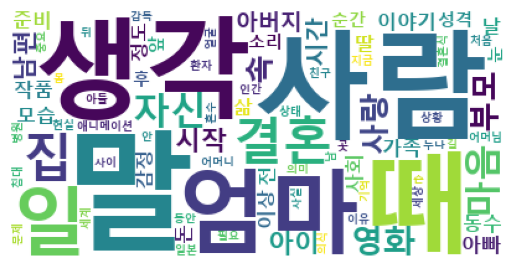

In [17]:
wc = WordCloud(
    font_path='C:/Windows/Fonts/malgunbd.ttf',
    background_color='white'    
).generate_from_frequencies(dict(top_80))
plt.imshow(wc)
plt.axis('off')
plt.show()